In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vencerlanz09/sea-animals-image-dataste")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sea-animals-image-dataste' dataset.
Path to dataset files: /kaggle/input/sea-animals-image-dataste


In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"Found GPU: {gpus}")
    # Optional: Set TensorFlow to use only the first GPU
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"{len(logical_gpus)} Logical GPUs configured.")
    except RuntimeError as e:
        # Visible devices must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found. TensorFlow will run on CPU.")

Found GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
1 Logical GPUs configured.


In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

dataset_path = path # 'path' variable comes from the previous cell execution

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    seed=42
)

# Get class names
class_names = train_ds.class_names
print(f"Class names: {class_names}")
NUM_CLASSES = len(class_names)

# Normalize images to [0, 1] range and cache for performance
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0 # Fixed: Cast to float32 before division
    return image, label

train_ds = train_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 13711 files belonging to 23 classes.
Using 10969 files for training.
Found 13711 files belonging to 23 classes.
Using 2742 files for validation.
Class names: ['Clams', 'Corals', 'Crabs', 'Dolphin', 'Eel', 'Fish', 'Jelly Fish', 'Lobster', 'Nudibranchs', 'Octopus', 'Otter', 'Penguin', 'Puffers', 'Sea Rays', 'Sea Urchins', 'Seahorse', 'Seal', 'Sharks', 'Shrimp', 'Squid', 'Starfish', 'Turtle_Tortoise', 'Whale']


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load the MobileNetV2 model pre-trained on ImageNet
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False, # Don't include the top classification layer
                         weights='imagenet')

# Freeze the base model layers so they are not updated during training
base_model.trainable = False

# Create a new model on top of the pre-trained base
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(NUM_CLASSES, activation='softmax')(x) # Output layer for our number of classes

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# Train the model
EPOCHS = 30 # You can adjust the number of epochs
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,424,919 (9.25 MB)

 Trainable params: 166,935 (652.09 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 56s 136ms/step - accuracy: 0.6954 - loss: 1.0380 - val_accuracy: 0.7451 - val_loss: 0.8470
Epoch 2/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8098 - loss: 0.6333 - val_accuracy: 0.7640 - val_loss: 0.8025
Epoch 3/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8536 - loss: 0.4900 - val_accuracy: 0.7648 - val_loss: 0.8248
Epoch 4/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.8853 - loss: 0.3902 - val_accuracy: 0.7615 - val_loss: 0.8604
Epoch 5/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9150 - loss: 0.3064 - val_accuracy: 0.7578 - val_loss: 0.8960
Epoch 6/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9367 - loss: 0.2422 - val_accuracy: 0.7608 - val_loss: 0.9442
Epoch 7/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9537 - loss: 0.1900 - val_accuracy: 0.7516 - val_loss: 1.0307
Epoch 8/30
343/343 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.9640 - loss: 0.1498 -

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)

print("\n--- Training Summary ---")
print(f"Final Training Loss: {history_df['loss'].iloc[-1]:.4f}")
print(f"Final Training Accuracy: {history_df['accuracy'].iloc[-1]:.4f}")
print(f"Final Validation Loss: {history_df['val_loss'].iloc[-1]:.4f}")
print(f"Final Validation Accuracy: {history_df['val_accuracy'].iloc[-1]:.4f}")


--- Training Summary ---
Final Training Loss: 0.0501
Final Training Accuracy: 0.9862
Final Validation Loss: 1.8104
Final Validation Accuracy: 0.7557


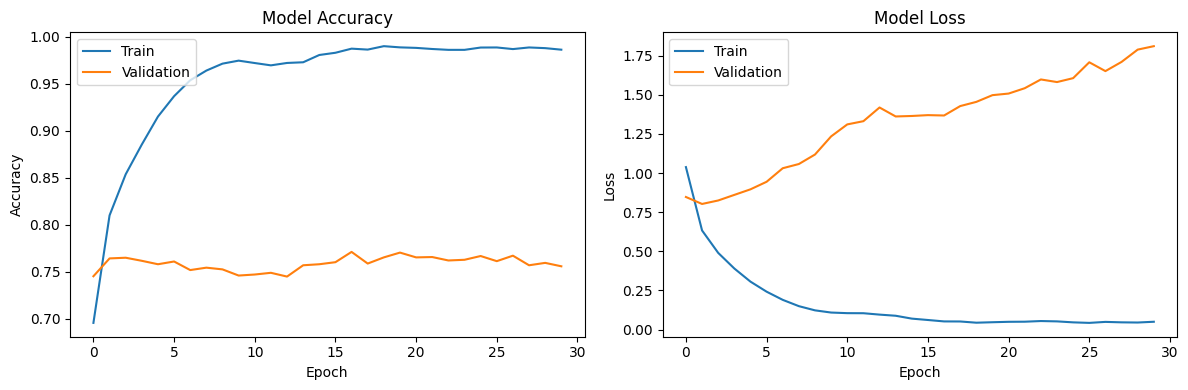

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()